# **Pre-requisites**

Necessary Libraries

In [ ]:
!pip install igraph

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 12.9 MB/s eta 0:00:00


In [ ]:
!pip install plotly

In [ ]:
!pip install torch_geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.1/63.1 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 19.6 MB/s eta 0:00:00


In [ ]:
import matplotlib.pyplot as plt
import igraph as ig
from igraph import Graph
import torch
from torch_geometric.data import Data
from sklearn.preprocessing import LabelEncoder
from torch_geometric.utils import subgraph, to_networkx
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import plotly.graph_objects as go
from torch_geometric.utils import subgraph, to_networkx
import networkx as nx
import matplotlib.pyplot as plt

Import Data

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
GRAPH_PATH = "/content/drive/MyDrive/I -TEAM FILES/Datasets/Comment_Struc (Features) - Graph.graphml"
g = Graph.Read_GraphML(GRAPH_PATH)
print(f"Loaded graph with {g.vcount()} nodes and {g.ecount()} edges")

<ipython-input-7-1bab8427e92a>:2: RuntimeWarning: Could not add vertex ids, there is already an 'id' vertex attribute. at src/io/graphml.c:488
  g = Graph.Read_GraphML(GRAPH_PATH)


Loaded graph with 325320 nodes and 6112052 edges


In [ ]:
edges = g.get_edgelist()
edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous()

In [ ]:
exclude_attrs = {"id", "label"}
feature_keys = [k for k in g.vs.attributes() if k not in exclude_attrs]

In [ ]:
x = torch.tensor([
    [v[attr] if v[attr] is not None else 0.0 for attr in feature_keys]
    for v in g.vs
], dtype=torch.float)

In [ ]:
labels_raw = [v["label"] for v in g.vs]

labeled_indices = [i for i, lbl in enumerate(labels_raw) if lbl not in [None, "None"]]
labeled_labels = [labels_raw[i] for i in labeled_indices]

#real labels
label_encoder = LabelEncoder()
encoded_known_labels = label_encoder.fit_transform(labeled_labels)

y = torch.full((len(labels_raw),), -1, dtype=torch.long)
for i, enc in zip(labeled_indices, encoded_known_labels):
    y[i] = enc

In [ ]:
# training mask of labeled nodes
train_mask = y != -1

In [ ]:
print("Encoded classes:", label_encoder.classes_)
print("Number of classes:", len(label_encoder.classes_))

Encoded classes: ['Cyborg' 'Human' 'Spam Bot' 'Troll']
Number of classes: 4


In [ ]:
data = Data(x=x, edge_index=edge_index, y=y)
data.train_mask = train_mask

In [ ]:
print(f"Feature matrix shape: {x.shape}")
print(f"Labeled nodes: {train_mask.sum().item()} out of {train_mask.shape[0]}")
print(f"Graph: {data}")

Feature matrix shape: torch.Size([325320, 16])
Labeled nodes: 840 out of 325320
Graph: Data(x=[325320, 16], edge_index=[2, 6112052], y=[325320], train_mask=[325320])


In [ ]:
print(g.vs.attributes())

['id', 'label', 'averageCommentLength', 'averageLinkUsage', 'averageResponseTime', 'engagement', 'averagePairwiseCommentDisimilarity', 'threadDeviation', 'innovationRate', 'averageLikesPerComment', 'replyRatio', 'commentTimeVariance', 'uniquePostsCommentedOn', 'uniqueNewsOutletsCommentedOn', 'averageCommentsPerPost', 'duplicateCommentRate', 'averageMediaUsage', 'numOfComments']


# **Visualization**

Graph for each class

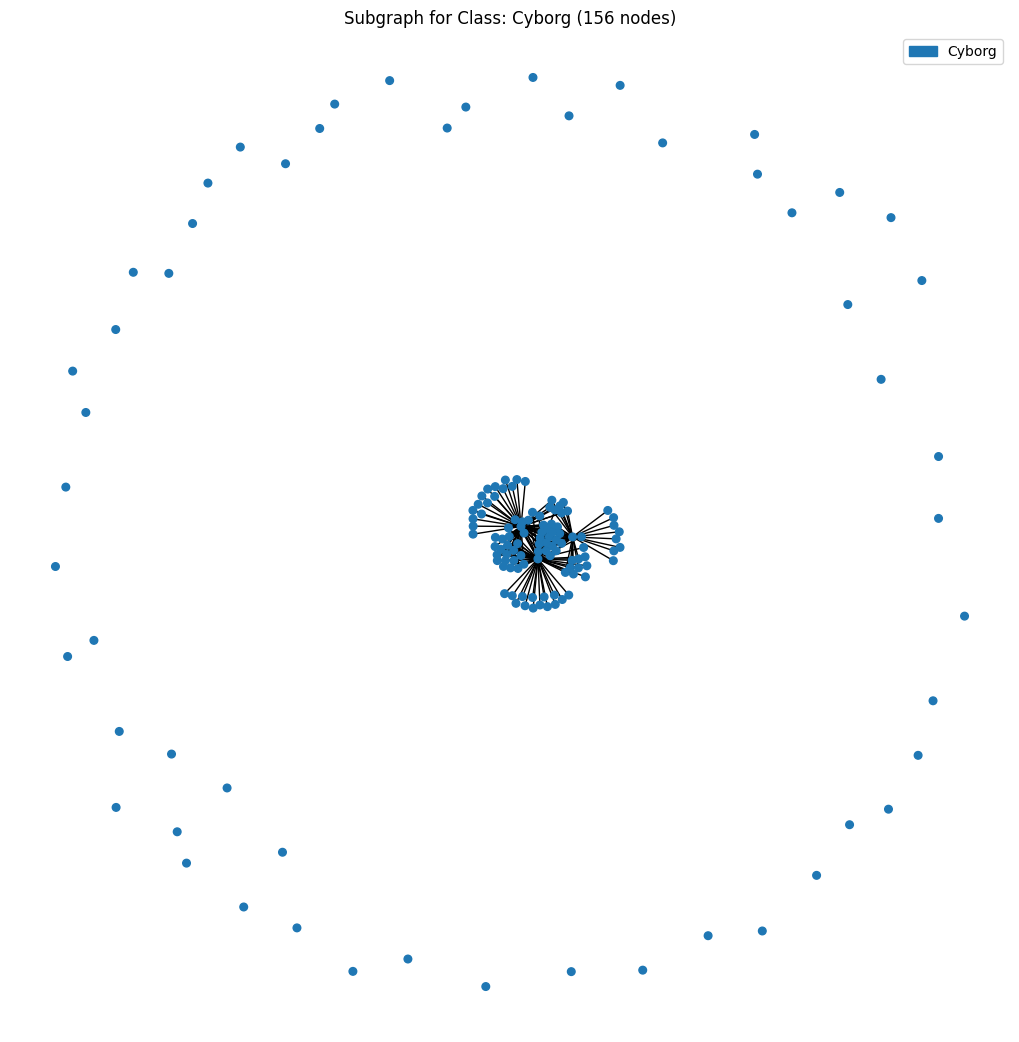

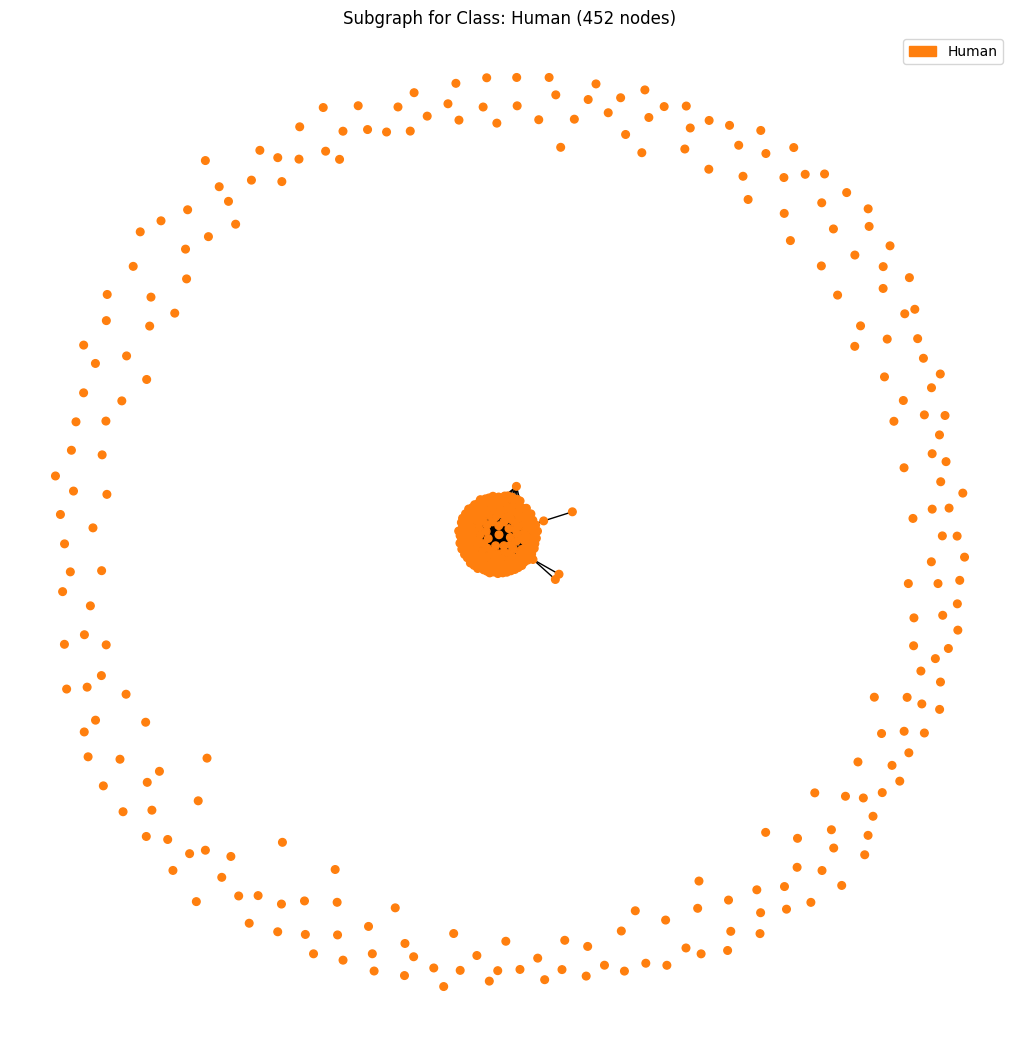

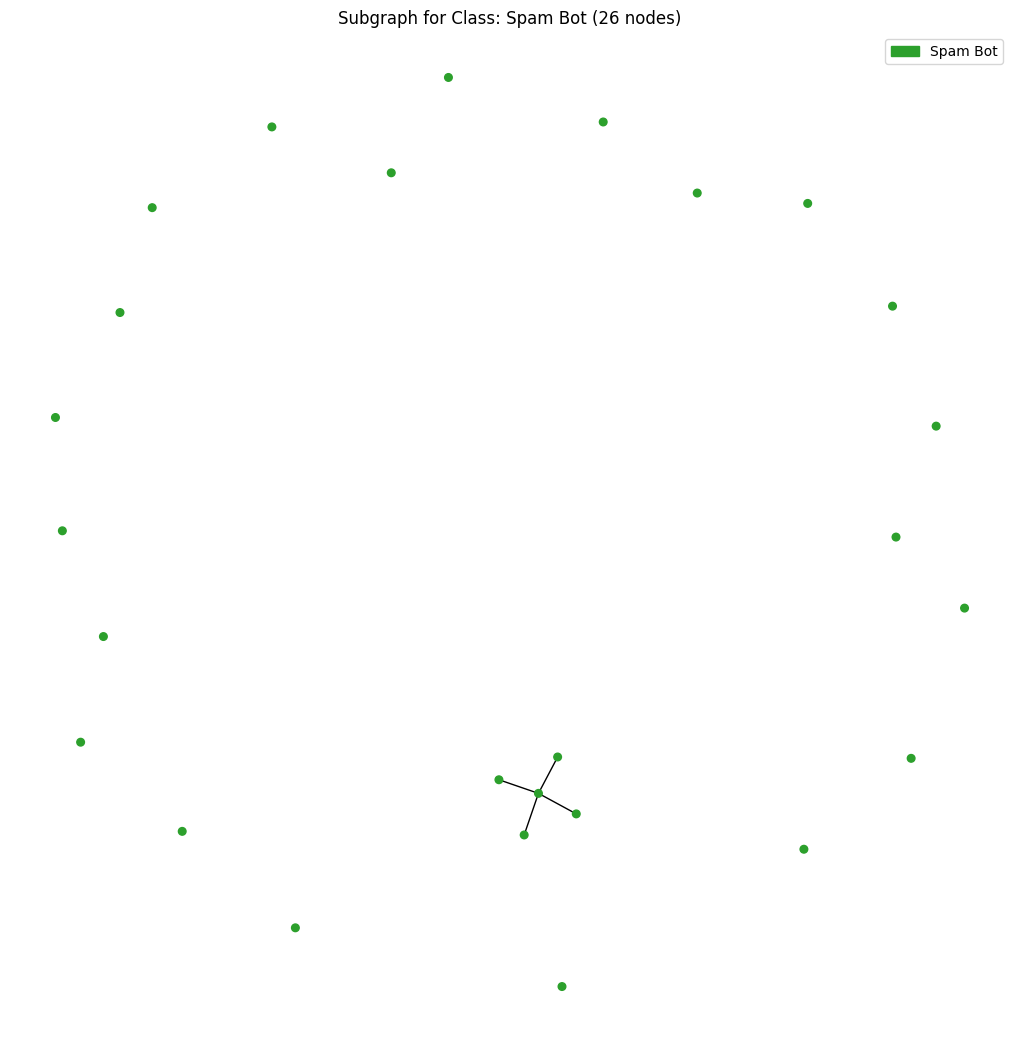

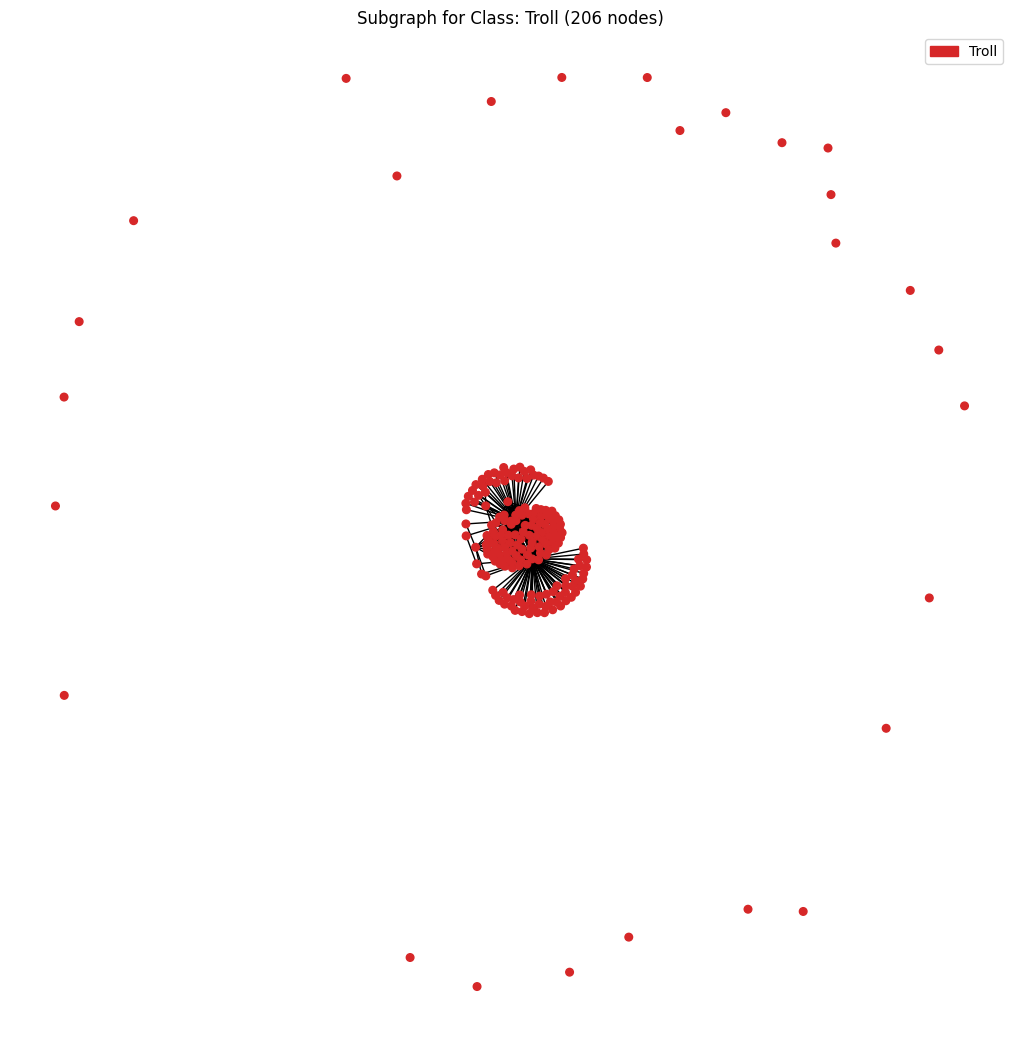

In [ ]:
# Prepare consistent colors
colormap = plt.cm.tab10  # good for up to 10 classes
class_colors = {i: colormap(i % 10) for i in range(len(label_encoder.classes_))}

for class_id, class_name in enumerate(label_encoder.classes_):
    class_indices = [i for i in labeled_indices if y[i] == class_id]
    if len(class_indices) < 5:
        continue

    class_tensor = torch.tensor(class_indices, dtype=torch.long)
    class_edge_index, _ = subgraph(class_tensor, edge_index, relabel_nodes=True)
    class_y = y[class_tensor]
    class_data = Data(x=x[class_tensor], edge_index=class_edge_index, y=class_y)

    G = to_networkx(class_data, to_undirected=True)

    # Assign same color to all nodes in this class
    node_colors = [class_colors[class_id]] * len(class_tensor)

    plt.figure(figsize=(10, 10))
    nx.draw(
        G,
        node_color=node_colors,
        node_size=30,
        with_labels=False
    )
    plt.title(f"Subgraph for Class: {class_name} ({len(class_indices)} nodes)")

    # Optional: Add a legend
    legend = [Patch(color=class_colors[class_id], label=class_name)]
    plt.legend(handles=legend, loc="upper right")

    plt.show()

Graph for labeled nodes

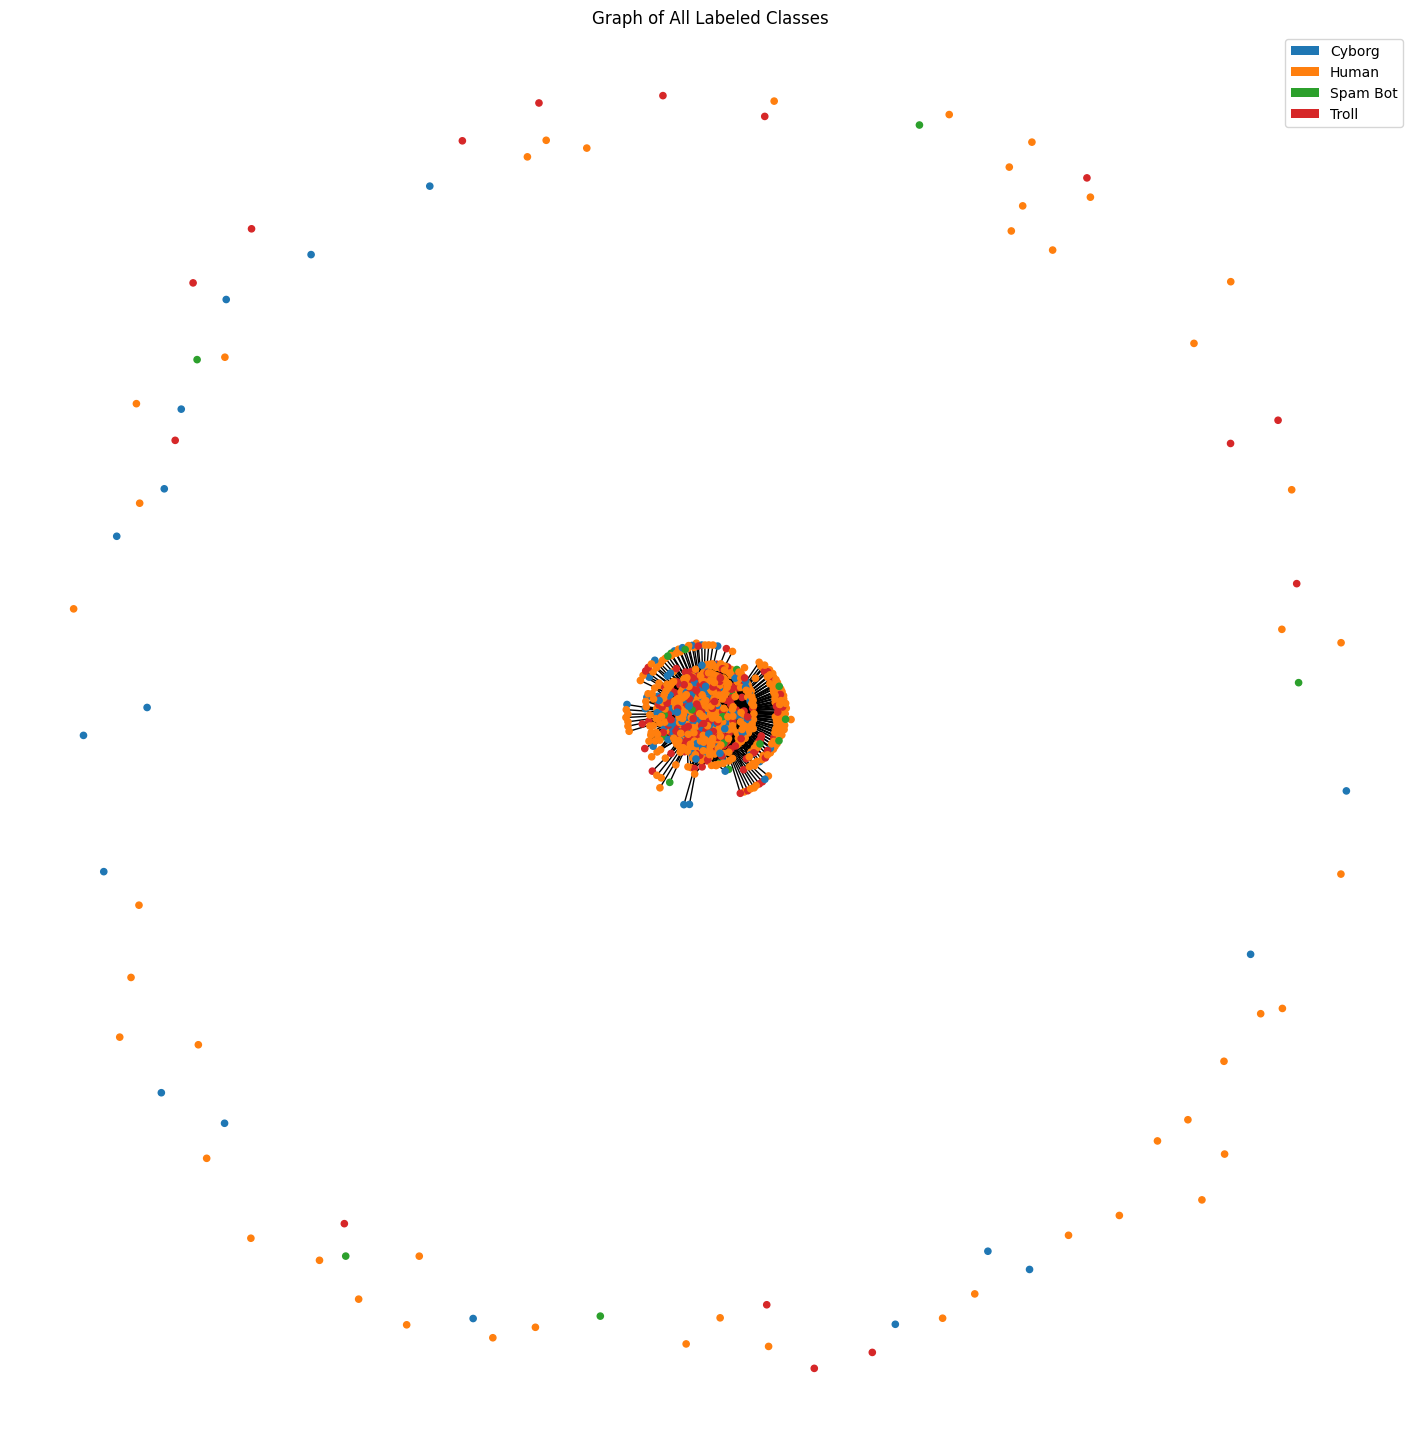

In [ ]:
# Use all labeled node indices
labeled_tensor = torch.tensor(labeled_indices, dtype=torch.long)

# Subgraph containing only labeled nodes
labeled_edge_index, _ = subgraph(labeled_tensor, edge_index, relabel_nodes=True)
labeled_y = y[labeled_tensor]

# Create PyG data object for labeled-only subgraph
labeled_data = Data(x=x[labeled_tensor], edge_index=labeled_edge_index, y=labeled_y)

# Convert to NetworkX
G_labeled = to_networkx(labeled_data, to_undirected=True)

# Assign color based on class
num_classes = len(label_encoder.classes_)
node_colors = [plt.cm.tab10(label.item() % 10) for label in labeled_y]  # supports up to 10 classes

# Plot
plt.figure(figsize=(14, 14))
nx.draw(
    G_labeled,
    node_color=node_colors,
    node_size=20,
    with_labels=False
)
# Add legend manually
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=plt.cm.tab10(i), label=cls)
    for i, cls in enumerate(label_encoder.classes_)
]
plt.legend(handles=legend_elements, loc="upper right")
plt.title("Graph of All Labeled Classes")
plt.show()

Interactive graph

In [ ]:
def plot_interactive_nx(G, node_colors, class_name):
    pos = nx.spring_layout(G, seed=42)  # fixed layout for reproducibility

    edge_x = []
    edge_y = []
    for edge in G.edges():
        x0, y0 = pos[edge[0]]
        x1, y1 = pos[edge[1]]
        edge_x += [x0, x1, None]
        edge_y += [y0, y1, None]

    edge_trace = go.Scatter(
        x=edge_x, y=edge_y,
        line=dict(width=0.5, color='#888'),
        hoverinfo='none',
        mode='lines'
    )

    node_x = []
    node_y = []
    for node in G.nodes():
        x, y = pos[node]
        node_x.append(x)
        node_y.append(y)

    node_trace = go.Scatter(
        x=node_x, y=node_y,
        mode='markers',
        hoverinfo='text',
        marker=dict(
            color=node_colors,
            size=10,
            line_width=2
        )
    )

    fig = go.Figure(data=[edge_trace, node_trace],
                    layout=go.Layout(
                        title=f"Interactive Graph - {class_name}",
                        showlegend=False,
                        hovermode='closest',
                        margin=dict(b=20,l=5,r=5,t=40),
                        xaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
                        yaxis=dict(showgrid=False, zeroline=False, showticklabels=False)
                    ))
    fig.show()

# Example usage for one class:

import matplotlib.colors as mcolors

# Convert matplotlib color to hex string for Plotly
def mpl_to_hex(color):
    return mcolors.to_hex(color)

for class_id, class_name in enumerate(label_encoder.classes_):
    class_indices = [i for i in labeled_indices if y[i] == class_id]
    if len(class_indices) < 5:
        continue
    class_tensor = torch.tensor(class_indices, dtype=torch.long)
    class_edge_index, _ = subgraph(class_tensor, edge_index, relabel_nodes=True)
    class_y = y[class_tensor]
    class_data = Data(x=x[class_tensor], edge_index=class_edge_index, y=class_y)

    G = to_networkx(class_data, to_undirected=True)

    hex_color = mpl_to_hex(class_colors[class_id])
    node_colors_plotly = [hex_color] * len(class_tensor)

    plot_interactive_nx(G, node_colors_plotly, class_name)
#    break  # remove break to generate for all classes one by one